<a href="https://colab.research.google.com/github/adharsh-codes/aiml-assignment/blob/main/area.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("brendan45774/test-file")

100%|██████████| 11.2k/11.2k [00:00<00:00, 12.2MB/s]

Extracting files...


In [2]:
import os
import pandas as pd

# List files in the downloaded directory
file_list = os.listdir(path)
print(f"Files in the dataset directory: {file_list}")

# Assuming the CSV file is the first one, or the only one
if file_list:
    data_file = os.path.join(path, file_list[0])
    df = pd.read_csv(data_file)
    print(f"Loaded data from: {data_file}")
    display(df.head())
else:
    print("No files found in the dataset directory.")

Files in the dataset directory: ['tested.csv']
Loaded data from: /root/.cache/kagglehub/datasets/brendan45774/test-file/versions/6/tested.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


Now that we have loaded the data, let's prepare it for model training. This includes identifying features and target, handling categorical variables, and splitting the data into training and testing sets.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Make a copy to avoid modifying the original dataframe directly
df_processed = df.copy()

# First, let's inspect the column names and data types to make an informed decision.
print(df_processed.info())

# Identify target and features
if 'species' in df_processed.columns:
    # Classification task
    target_column = 'species'
    # Impute missing values in numerical features
    for col in df_processed.select_dtypes(include=['number']).columns:
        if df_processed[col].isnull().any():
            df_processed[col].fillna(df_processed[col].mean(), inplace=True)
    features = df_processed.drop(columns=[target_column])

    # Encode target variable if it's categorical
    le = LabelEncoder()
    y = le.fit_transform(df_processed[target_column])
    print(f"Target classes: {le.classes_}")
    print("Performing Classification.")
elif 'variety' in df_processed.columns:
    # Classification task
    target_column = 'variety'
    # Impute missing values in numerical features
    for col in df_processed.select_dtypes(include=['number']).columns:
        if df_processed[col].isnull().any():
            df_processed[col].fillna(df_processed[col].mean(), inplace=True)
    features = df_processed.drop(columns=[target_column])

    # Encode target variable if it's categorical
    le = LabelEncoder()
    y = le.fit_transform(df_processed[target_column])
    print(f"Target classes: {le.classes_}")
    print("Performing Classification.")
else:
    # Assuming regression task if no clear classification target, will pick the last column as target if numerical.
    numerical_cols = df_processed.select_dtypes(include=['number']).columns.tolist()
    if len(numerical_cols) >= 2:
        target_column = numerical_cols[-1] # Pick the last numerical column as target

        # Impute missing values in the target column
        if df_processed[target_column].isnull().any():
            df_processed[target_column].fillna(df_processed[target_column].mean(), inplace=True)

        # Impute missing values in numerical features (excluding the target column)
        feature_numerical_cols = [col for col in numerical_cols if col != target_column]
        for col in feature_numerical_cols:
            if df_processed[col].isnull().any():
                df_processed[col].fillna(df_processed[col].mean(), inplace=True)

        features = df_processed.drop(columns=[target_column])
        y = df_processed[target_column]
        print(f"Target column for regression: {target_column}")
        print("Performing Regression.")
    else:
        raise ValueError("Could not identify a suitable target for classification or regression.")

# Handle categorical features in 'features' using one-hot encoding if any
X = pd.get_dummies(features)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB
None
Target column for regression: Fare
Performing Regression.

Shape of X_train: (334, 868)
Shape of X_test: (84, 868)
Shape of y_train: (334,)
Shape of y_test: (84,)


/tmp/ipykernel_7690/3531904882.py:47: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[target_column].fillna(df_processed[target_column].mean(), inplace=True)
/tmp/ipykernel_7690/3531904882.py:53: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[c

Now, let's train and evaluate the specified models: Decision Tree, Random Forest, Logistic Regression, and Linear Regression. Since the target variable identification code is dynamic (classification vs. regression), I'll make sure to use appropriate models for each case.

In [6]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
import numpy as np

def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name, task_type):
    print(f"\n--- Training {model_name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if task_type == 'classification':
        accuracy = accuracy_score(y_test, y_pred)
        print(f"{model_name} Accuracy: {accuracy:.4f}")
    elif task_type == 'regression':
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        print(f"{model_name} Mean Squared Error (MSE): {mse:.4f}")
        print(f"{model_name} Root Mean Squared Error (RMSE): {rmse:.4f}")
        print(f"{model_name} R-squared (R2): {r2:.4f}")
    else:
        print("Unknown task type.")

# Determine task type based on the target variable
task_type = 'classification' if 'le' in locals() else 'regression'

if task_type == 'classification':
    # Decision Tree Classifier
    dt_classifier = DecisionTreeClassifier(random_state=42)
    train_and_evaluate_model(dt_classifier, X_train, y_train, X_test, y_test, "Decision Tree Classifier", task_type)

    # Random Forest Classifier
    rf_classifier = RandomForestClassifier(random_state=42)
    train_and_evaluate_model(rf_classifier, X_train, y_train, X_test, y_test, "Random Forest Classifier", task_type)

    # Logistic Regression Classifier
    # Increase max_iter to ensure convergence for some datasets
    lr_classifier = LogisticRegression(max_iter=1000, random_state=42)
    train_and_evaluate_model(lr_classifier, X_train, y_train, X_test, y_test, "Logistic Regression", task_type)

elif task_type == 'regression':
    # Decision Tree Regressor
    dt_regressor = DecisionTreeRegressor(random_state=42)
    train_and_evaluate_model(dt_regressor, X_train, y_train, X_test, y_test, "Decision Tree Regressor", task_type)

    # Random Forest Regressor
    rf_regressor = RandomForestRegressor(random_state=42)
    train_and_evaluate_model(rf_regressor, X_train, y_train, X_test, y_test, "Random Forest Regressor", task_type)

    # Linear Regression
    lr_regressor = LinearRegression()
    train_and_evaluate_model(lr_regressor, X_train, y_train, X_test, y_test, "Linear Regression", task_type)



--- Training Decision Tree Regressor ---
Decision Tree Regressor Mean Squared Error (MSE): 826.5199
Decision Tree Regressor Root Mean Squared Error (RMSE): 28.7493
Decision Tree Regressor R-squared (R2): 0.6113

--- Training Random Forest Regressor ---
Random Forest Regressor Mean Squared Error (MSE): 799.7005
Random Forest Regressor Root Mean Squared Error (RMSE): 28.2790
Random Forest Regressor R-squared (R2): 0.6239

--- Training Linear Regression ---
Linear Regression Mean Squared Error (MSE): 852.4906
Linear Regression Root Mean Squared Error (RMSE): 29.1974
Linear Regression R-squared (R2): 0.5991


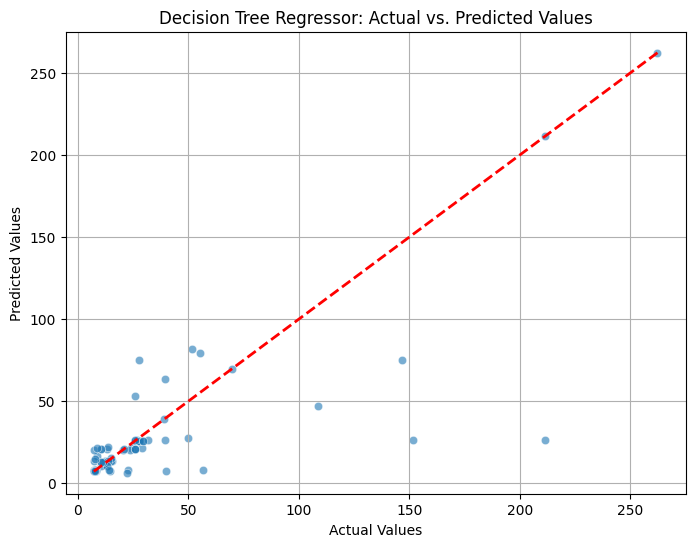

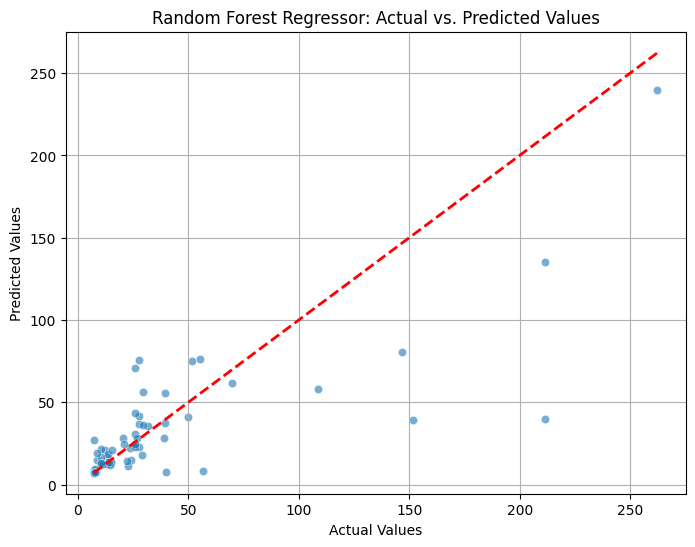

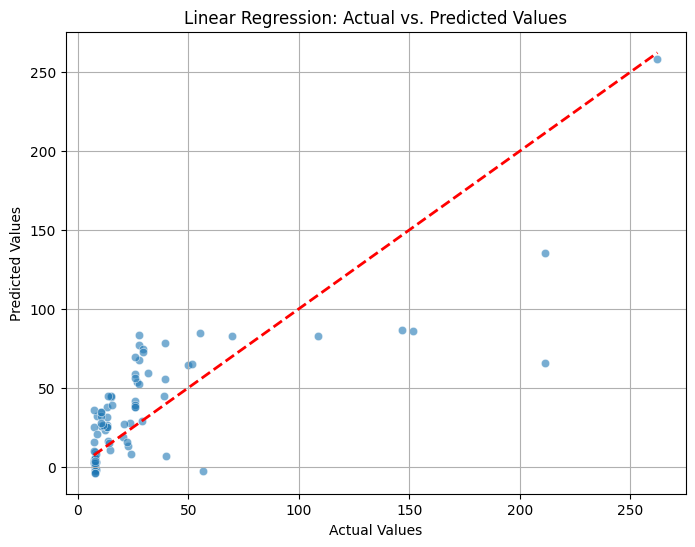

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_predictions(y_test, y_pred, model_name):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{model_name}: Actual vs. Predicted Values')
    plt.grid(True)
    plt.show()

# Assuming task_type is 'regression' and models are trained
if task_type == 'regression':
    # Decision Tree Regressor
    dt_pred = dt_regressor.predict(X_test)
    plot_predictions(y_test, dt_pred, "Decision Tree Regressor")

    # Random Forest Regressor
    rf_pred = rf_regressor.predict(X_test)
    plot_predictions(y_test, rf_pred, "Random Forest Regressor")

    # Linear Regression
    lr_pred = lr_regressor.predict(X_test)
    plot_predictions(y_test, lr_pred, "Linear Regression")
